<a href="https://colab.research.google.com/github/nrios256-create/analisis_datos/blob/main/conversion__object__a__categorica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
import pandas as pd #convierte archivos en tablas inteligentes
import seaborn as sns #graficos mas bonitos
import matplotlib.pyplot as plt #graficos

In [75]:
plantas= pd.read_csv('https://raw.githubusercontent.com/Gustavo-Bruges/ciencia-de-datos-unab/refs/heads/datos/edible_plants.csv')

In [76]:
plantas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   taxonomic_name           140 non-null    object 
 1   common_name              140 non-null    object 
 2   cultivation              140 non-null    object 
 3   sunlight                 140 non-null    object 
 4   water                    140 non-null    object 
 5   preferred_ph_lower       140 non-null    float64
 6   preferred_ph_upper       140 non-null    float64
 7   nutrients                140 non-null    object 
 8   soil                     94 non-null     object 
 9   season                   67 non-null     object 
 10  temperature_class        140 non-null    object 
 11  temperature_germination  104 non-null    object 
 12  temperature_growing      58 non-null     object 
 13  days_germination         102 non-null    object 
 14  days_harvest             1

<Axes: >

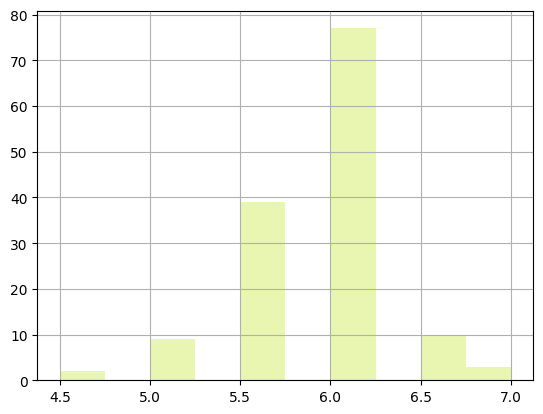

In [77]:
plantas['preferred_ph_lower'].hist()

In [78]:
plantas['soil'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 140 entries, 0 to 139
Series name: soil
Non-Null Count  Dtype 
--------------  ----- 
94 non-null     object
dtypes: object(1)
memory usage: 1.2+ KB


In [79]:
plantas['soil'].nbytes

1120

In [80]:
#convertir mi variable object a variable categorica
plantas['soil'] = plantas['soil'].astype('category') #buscar variables objects que no se repitan tanto

In [81]:
#elija dos variables y transformelas a la categoria y justifique su eleccion

In [82]:
plantas['cultivation'].value_counts(normalize=True)*100 #para mostrarlo como porcentaje normalize=true * 100

,proportion
cultivation,
Miscellaneous,46.428571
Brassica,15.000000
Legume,7.142857
Allium,6.428571
Umbelliferae,5.714286
Cucurbit,5.714286
Solanaceae,4.285714
Lamiaceae,2.857143
Salad,2.142857


In [83]:
#agrupar
#buscar una variable que agrupe y genere medidas con una numerica
plantas.groupby('cultivation')['preferred_ph_lower'].value_counts()

cultivation     preferred_ph_lower
Allium          6.0                    7
                5.5                    1
                6.5                    1
Brassica        6.0                   16
                5.5                    3
                6.5                    2
Brassicas       5.0                    1
Chenopodiaceae  6.0                    3
Cucurbit        6.0                    5
                5.5                    3
Lamiaceae       6.0                    2
                5.5                    1
                7.0                    1
Legume          6.0                   10
Miscellaneous   6.0                   28
                5.5                   23
                5.0                    7
                6.5                    7
Salad           6.0                    3
Solanaceae      4.5                    2
                5.5                    2
                7.0                    2
Solanum         5.5                    2
Umbelliferae    5.5                    4
                6.0                    3
                5.0                    1
Name: count, dtype: int64

In [84]:
plantas.groupby('cultivation')[['preferred_ph_lower','preferred_ph_upper']].agg(['max','min','mean'])

preferred_ph_lower                preferred_ph_upper       \
                              max  min      mean                max  min   
cultivation                                                                
Allium                        6.5  5.5  6.000000                7.5  7.0   
Brassica                      6.5  5.5  5.976190                7.5  7.0   
Brassicas                     5.0  5.0  5.000000                7.5  7.5   
Chenopodiaceae                6.0  6.0  6.000000                7.5  7.0   
Cucurbit                      6.0  5.5  5.812500                7.5  7.0   
Lamiaceae                     7.0  5.5  6.125000                8.0  6.5   
Legume                        6.0  6.0  6.000000                7.5  6.5   
Miscellaneous                 6.5  5.0  5.769231                8.0  6.0   
Salad                         6.0  6.0  6.000000                7.0  6.7   
Solanaceae                    7.0  4.5  5.666667                8.5  6.0   
Solanum                       5.5  5.5  5.500000                7.5  7.5   
Umbelliferae                  6.0  5.0  5.625000                7.5  6.5   

                          
                    mean  
cultivation               
Allium          7.166667  
Brassica        7.333333  
Brassicas       7.500000  
Chenopodiaceae  7.333333  
Cucurbit        7.125000  
Lamiaceae       7.375000  
Legume          7.080000  
Miscellaneous   7.007692  
Salad           6.900000  
Solanaceae      7.166667  
Solanum         7.500000  
Umbelliferae    7.062500

In [85]:
colores = [
    "#FFB6C1",  # rosa claro
    "#FF69B4",  # rosa fuerte
    "#FFC0CB",  # pink
    "#DDA0DD",  # lila
    "#E6E6FA",  # lavanda
    "#F8BBD0",  # rosa pastel
    "#F48FB1",  # rosado suave
    "#CE93D8",  # morado claro
    "#F06292",  # rosa intermedio
    "#BA68C8",  # violeta suave
    "#F9C4D2"   # rosita bebé
]

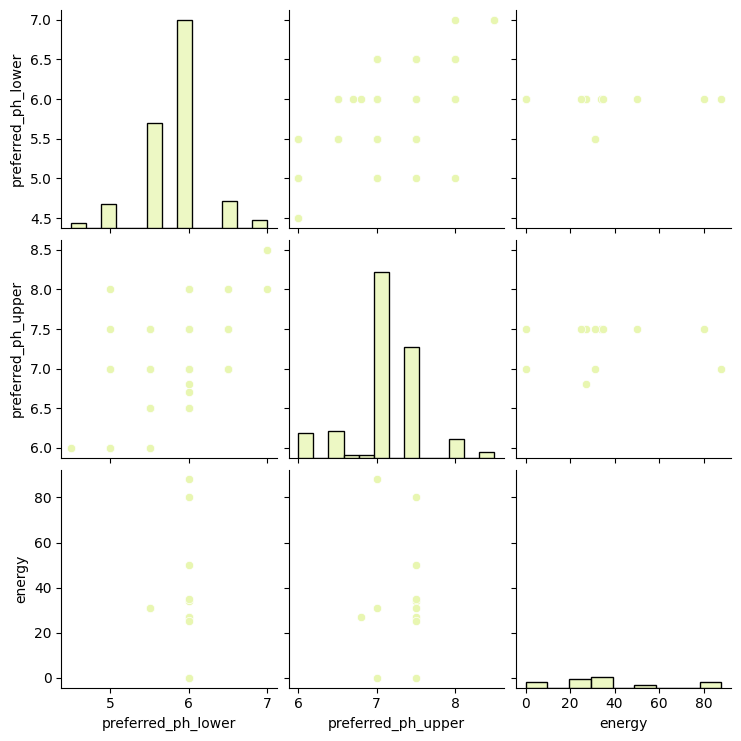

In [98]:
sns.pairplot(plantas) #comparacion de todas las variables numericas
plt.show()

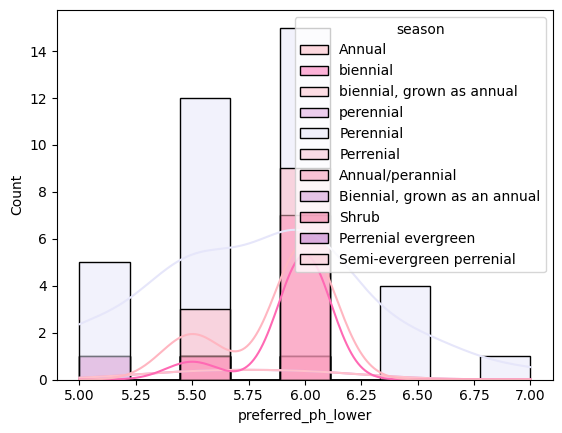

In [95]:
sns.set_palette('YlGnBu')
sns.histplot(data=plantas, x='preferred_ph_lower', hue='season', kde=True, palette=colores)
plt.show() #recuerda que no me dejaba cambiar el color de la grafica entonces me toco crear los colores arriba para poder llamarlo aca

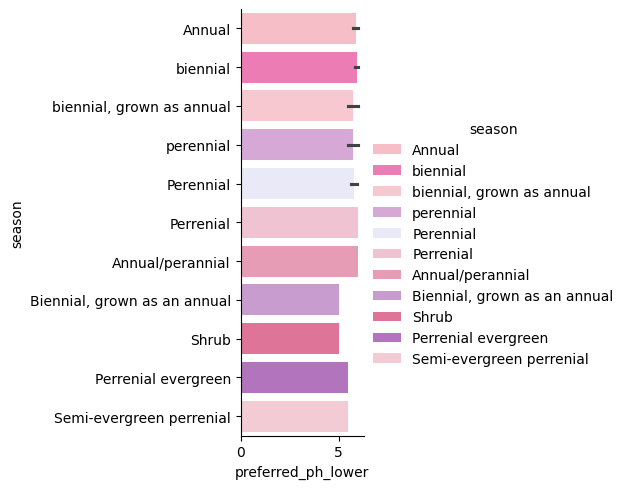

In [94]:
sns.catplot(data=plantas, y='season', x='preferred_ph_lower', kind='bar', hue='season', palette=colores)
plt.show()